In [1]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from qiskit.circuit.library import pauli_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel


import os
from multiprocessing import Process


os.makedirs("../results/experiment_15_v3", exist_ok=True)

In [2]:
dataset = pd.read_csv("../dataset/riemann_features.csv")

features = pd.read_csv("../results/data_analysis/selected_features.csv")["feature"].tolist()

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1600, 94) (1600,)
(400, 94) (400,)


# Classical SVR

In [12]:
def run_classical_experiment():
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    n_features = [i for i in range(2, 11)]

    for n in n_features:
        print(f"Running experiment for group: Rank Aggregation with {n} features")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": n
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/classical_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["Features"], plot_df["MSE"], 'b-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Clássico RBF)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running experiment for group: Rank Aggregation with 2 features
Running experiment for group: Rank Aggregation with 3 features
Running experiment for group: Rank Aggregation with 4 features
Running experiment for group: Rank Aggregation with 5 features
Running experiment for group: Rank Aggregation with 6 features
Running experiment for group: Rank Aggregation with 7 features
Running experiment for group: Rank Aggregation with 8 features
Running experiment for group: Rank Aggregation with 9 features
Running experiment for group: Rank Aggregation with 10 features
        MSE        R2  Best C  Best epsilon Best gamma  Features
0  0.003348  0.958818      10         0.001      scale         9
1  0.004294  0.947179      10         0.001      scale         6
2  0.005017  0.938285       5         0.001      scale        10
3  0.005018  0.938264      10         0.001      scale         8
4  0.005321  0.934541      10         0.001      scale         7
5  0.005627  0.930776      10         0.01

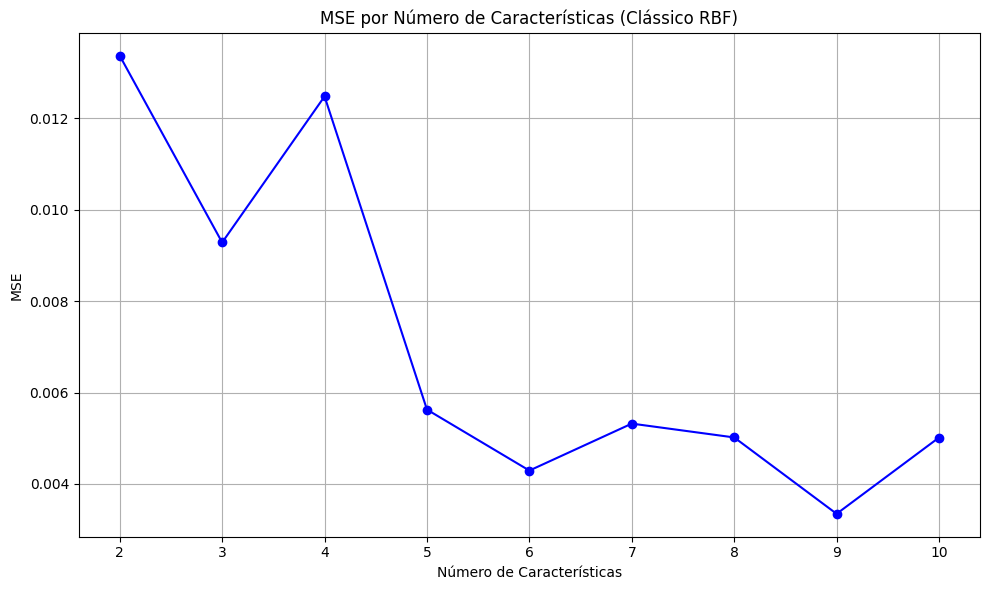

In [13]:
run_classical_experiment()

# Quantum SVR - DoubleAngleEntangledFeatureMap

In [3]:
def feature_map(x, wires, rotation_first="X", rotation_second="Y"):
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_first)
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_second)


def make_simple_kernel(n_qubits, rotation_first="X", rotation_second="Y"):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map(x1, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        qml.adjoint(feature_map)(x2, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## DoubleAngleEntangledFeatureMap Circuit

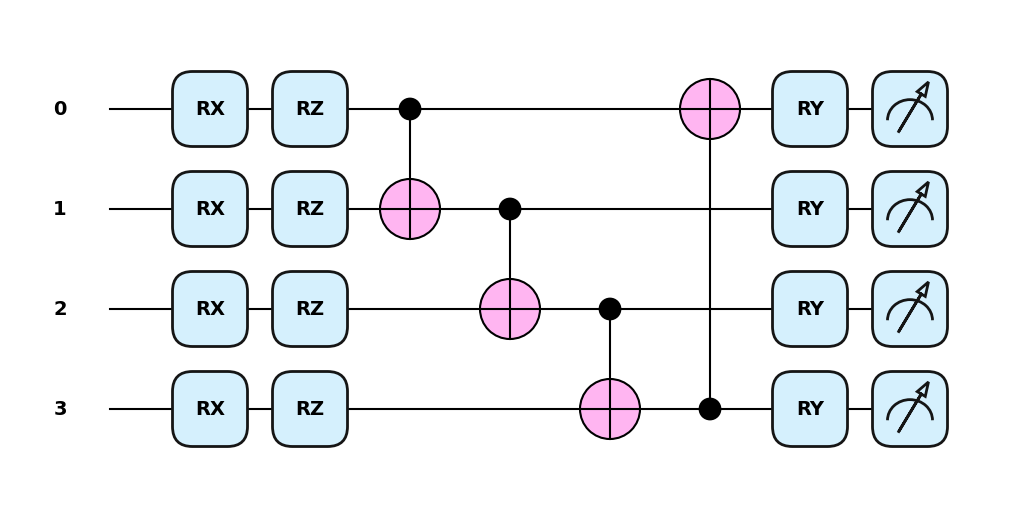

In [52]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/angle_entangled_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [4]:
def fourier_feature_map(x, wires):
    for i in range(len(wires)):
        qml.RX(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    for i in range(len(wires)-1):
        qml.CNOT(wires=[wires[i], wires[i+1]])

    for i in range(len(wires)):
        qml.RZ(np.sin(x[i]) + np.cos(2*x[i]), wires=wires[i])


def make_fourier_kernel(n_qubits):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        fourier_feature_map(x1, wires=wires)
        qml.adjoint(fourier_feature_map)(x2, wires=wires)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

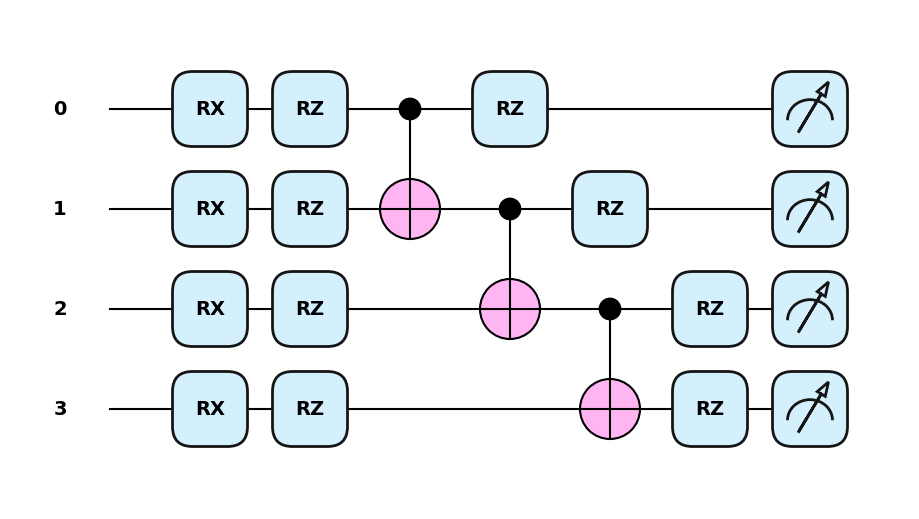

In [54]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    fourier_feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/fourier_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [5]:
def run_simple_experiment():
    results = []
    n_qubits = list(range(2, 11))
    kernels = {f"{n}_XY": (make_simple_kernel(n, rotation_first="X", rotation_second="Y"), n) for n in n_qubits}

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, MSE: {mse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "mse": mse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("mse")\
        .to_csv("../results/experiment_15_v3/simple_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["mse"], 'g-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Angle Encoding)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [56]:
def riemann_advanced_data_map(x):
    x = np.asarray(x)

    x_safe = x + 1e-8

    theta_like = np.sum(x_safe * np.log(x_safe))
    val = np.cos(theta_like)

    for i in range(len(x) - 1):
        val += 0.3 * np.cos(x[i] - x[i+1])
        val += 0.3 * np.sin(x[i] * x[i+1])

    return val


def preproc_rbf_s1(X: np.ndarray) -> np.ndarray:
    return np.exp(-(X ** 2) / 2.0)


def run_quantum_experiment_pauli_feature_map_default():
    results = []
    n_features = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    param_grid = {
        "C": [0.1, 1, 5, 10],
        "epsilon": [0.001, 0.01, 0.1, 0.5]
    }

    for n in n_features:
        print(f"Running quantum experiment with {n} features using Pauli feature map")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        scaler_X = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = scaler_X.fit_transform(X_train_subset)
        X_test_scaled = scaler_X.transform(X_test_subset)

        X_train_scaled = preproc_rbf_s1(X_train_scaled)
        X_test_scaled  = preproc_rbf_s1(X_test_scaled)

        fm = pauli_feature_map(
            feature_dimension=n,
            paulis=["Y", "YY"],
            entanglement="full",
            reps=2,
        )

        kernel = FidelityStatevectorKernel(feature_map=fm)

        kernel_matrix = kernel.evaluate(X_train_scaled)
        kernel_matrix_test = kernel.evaluate(X_test_scaled, X_train_scaled)

        grid = GridSearchCV(
            SVR(kernel="precomputed"),
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(kernel_matrix, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(kernel_matrix_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Results for DEFAULT {n} features: MSE = {mse:.4f}, R2 = {r2:.4f}")

        results.append({
            "N Features": n,
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["C"],
            "Best epsilon": grid.best_params_["epsilon"],
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/quantum_pauli_results_default.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("N Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["N Features"], plot_df["MSE"], 'r-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Quantum Pauli Feature Map)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_df

In [57]:
def riemann_advanced_data_map(x):
    x = np.asarray(x)

    x_safe = x + 1e-8

    theta_like = np.sum(x_safe * np.log(x_safe))
    val = np.cos(theta_like)

    for i in range(len(x) - 1):
        val += 0.3 * np.cos(x[i] - x[i+1])
        val += 0.3 * np.sin(x[i] * x[i+1])

    return val


def preproc_rbf_s1(X: np.ndarray) -> np.ndarray:
    return np.exp(-(X ** 2) / 2.0)


def run_quantum_experiment_pauli_feature_map():
    results = []
    n_features = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    param_grid = {
        "C": [0.1, 1, 5, 10],
        "epsilon": [0.001, 0.01, 0.1, 0.5]
    }

    for n in n_features:
        print(f"Running quantum experiment with {n} features using Pauli feature map")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        scaler_X = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = scaler_X.fit_transform(X_train_subset)
        X_test_scaled = scaler_X.transform(X_test_subset)

        X_train_scaled = preproc_rbf_s1(X_train_scaled)
        X_test_scaled  = preproc_rbf_s1(X_test_scaled)

        fm = pauli_feature_map(
            feature_dimension=n,
            paulis=["Y", "YY"],
            entanglement="full",
            reps=2,
            data_map_func=riemann_advanced_data_map,
        )

        kernel = FidelityStatevectorKernel(feature_map=fm)

        kernel_matrix = kernel.evaluate(X_train_scaled)
        kernel_matrix_test = kernel.evaluate(X_test_scaled, X_train_scaled)

        grid = GridSearchCV(
            SVR(kernel="precomputed"),
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(kernel_matrix, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(kernel_matrix_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Results for {n} features: MSE = {mse:.4f}, R2 = {r2:.4f}")

        results.append({
            "N Features": n,
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["C"],
            "Best epsilon": grid.best_params_["epsilon"],
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/quantum_pauli_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("N Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["N Features"], plot_df["MSE"], 'r-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Quantum Pauli Feature Map)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_df

Running quantum experiment with 2 features using Pauli feature map
Results for 2 features: MSE = 0.0814, R2 = -0.0013
Running quantum experiment with 3 features using Pauli feature map
Results for 3 features: MSE = 0.0795, R2 = 0.0214
Running quantum experiment with 4 features using Pauli feature map
Results for 4 features: MSE = 0.0504, R2 = 0.3800
Running quantum experiment with 5 features using Pauli feature map
Results for 5 features: MSE = 0.0189, R2 = 0.7670
Running quantum experiment with 6 features using Pauli feature map
Results for 6 features: MSE = 0.0113, R2 = 0.8608
Running quantum experiment with 7 features using Pauli feature map
Results for 7 features: MSE = 0.0109, R2 = 0.8665
Running quantum experiment with 8 features using Pauli feature map
Results for 8 features: MSE = 0.0080, R2 = 0.9012
Running quantum experiment with 9 features using Pauli feature map
Results for 9 features: MSE = 0.0058, R2 = 0.9285
Running quantum experiment with 10 features using Pauli feature

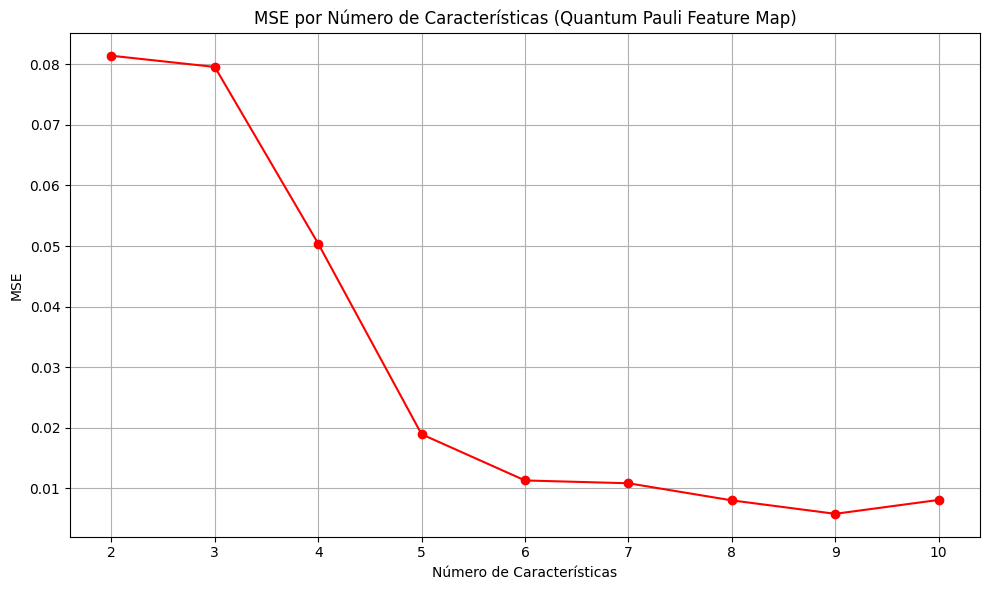

,N Features,MSE,R2,Best C,Best epsilon
0,9,0.005811,0.928512,10,0.010
1,8,0.008030,0.901213,10,0.001
2,10,0.008103,0.900311,10,0.010
3,7,0.010852,0.866498,10,0.001
4,6,0.011316,0.860789,10,0.010
5,5,0.018938,0.767022,10,0.100
6,4,0.050396,0.380021,1,0.001
7,3,0.079545,0.021434,10,0.500
8,2,0.081394,-0.001316,5,0.100


In [58]:
run_quantum_experiment_pauli_feature_map()

Running quantum experiment with 2 features using Pauli feature map
Results for DEFAULT 2 features: MSE = 0.0724, R2 = 0.1091
Running quantum experiment with 3 features using Pauli feature map
Results for DEFAULT 3 features: MSE = 0.0668, R2 = 0.1779
Running quantum experiment with 4 features using Pauli feature map
Results for DEFAULT 4 features: MSE = 0.0551, R2 = 0.3222
Running quantum experiment with 5 features using Pauli feature map
Results for DEFAULT 5 features: MSE = 0.0560, R2 = 0.3112
Running quantum experiment with 6 features using Pauli feature map
Results for DEFAULT 6 features: MSE = 0.0394, R2 = 0.5150
Running quantum experiment with 7 features using Pauli feature map
Results for DEFAULT 7 features: MSE = 0.0480, R2 = 0.4094
Running quantum experiment with 8 features using Pauli feature map
Results for DEFAULT 8 features: MSE = 0.0405, R2 = 0.5019
Running quantum experiment with 9 features using Pauli feature map
Results for DEFAULT 9 features: MSE = 0.0350, R2 = 0.5698


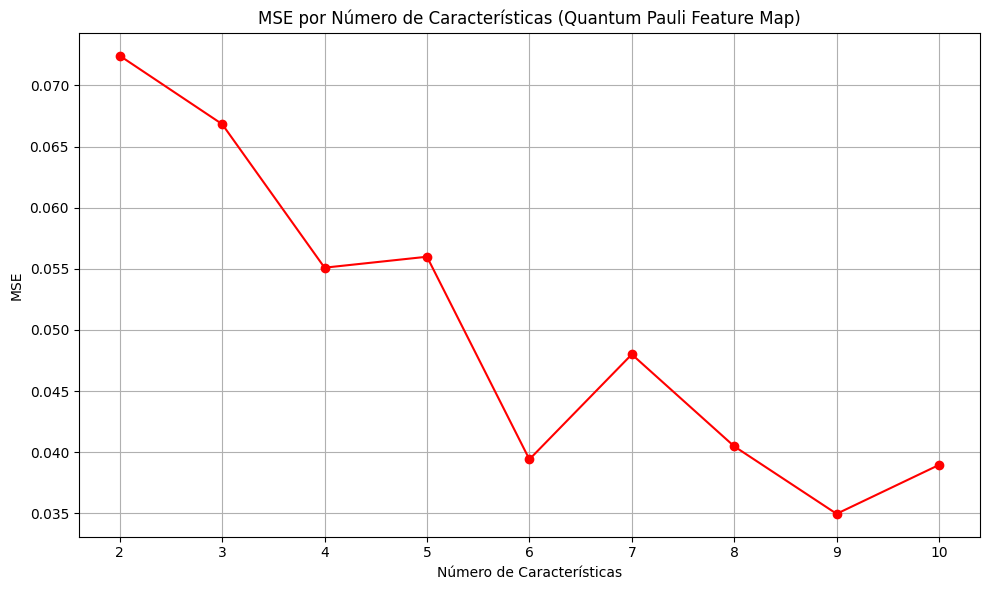

,N Features,MSE,R2,Best C,Best epsilon
0,9,0.034971,0.569781,1.0,0.001
1,10,0.038968,0.520612,1.0,0.001
2,6,0.039423,0.515009,1.0,0.100
3,8,0.040488,0.501906,1.0,0.001
4,7,0.048008,0.409400,5.0,0.100
5,4,0.055094,0.322225,1.0,0.100
6,5,0.055988,0.311226,0.1,0.100
7,3,0.066830,0.177853,0.1,0.100
8,2,0.072422,0.109062,0.1,0.100


In [59]:
run_quantum_experiment_pauli_feature_map_default()

In [6]:
def run_fourier_experiment():
    results = []
    n_qubits = list(range(2, 11))
    kernels = {f"{n}_Fourier": (make_fourier_kernel(n), n) for n in n_qubits}

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, MSE: {mse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "mse": mse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("mse")\
        .to_csv("../results/experiment_15_v3/fourier_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["mse"], 'm-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Fourier Kernel)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running kernel 2_Fourier
Running kernel 2_XY
Kernel: 2_Fourier, MSE: 0.0305, R^2: 0.6249
Running kernel 3_Fourier
Kernel: 2_XY, MSE: 0.0435, R^2: 0.4654
Running kernel 3_XY
Kernel: 3_Fourier, MSE: 0.0173, R^2: 0.7870
Running kernel 4_Fourier
Kernel: 3_XY, MSE: 0.0217, R^2: 0.7329
Running kernel 4_XY
Kernel: 4_Fourier, MSE: 0.0167, R^2: 0.7942
Running kernel 5_Fourier
Kernel: 4_XY, MSE: 0.0208, R^2: 0.7437
Running kernel 5_XY
Kernel: 5_Fourier, MSE: 0.0088, R^2: 0.8914
Running kernel 6_Fourier
Kernel: 5_XY, MSE: 0.0103, R^2: 0.8737
Running kernel 6_XY
Kernel: 6_Fourier, MSE: 0.0061, R^2: 0.9250
Running kernel 7_Fourier
Kernel: 6_XY, MSE: 0.0079, R^2: 0.9032
Running kernel 7_XY
Kernel: 7_Fourier, MSE: 0.0058, R^2: 0.9292
Running kernel 8_Fourier
Kernel: 7_XY, MSE: 0.0075, R^2: 0.9082
Running kernel 8_XY
Kernel: 8_Fourier, MSE: 0.0053, R^2: 0.9344
Running kernel 9_Fourier
Kernel: 8_XY, MSE: 0.0068, R^2: 0.9168
Running kernel 9_XY
Kernel: 9_Fourier, MSE: 0.0038, R^2: 0.9529
Running kernel 

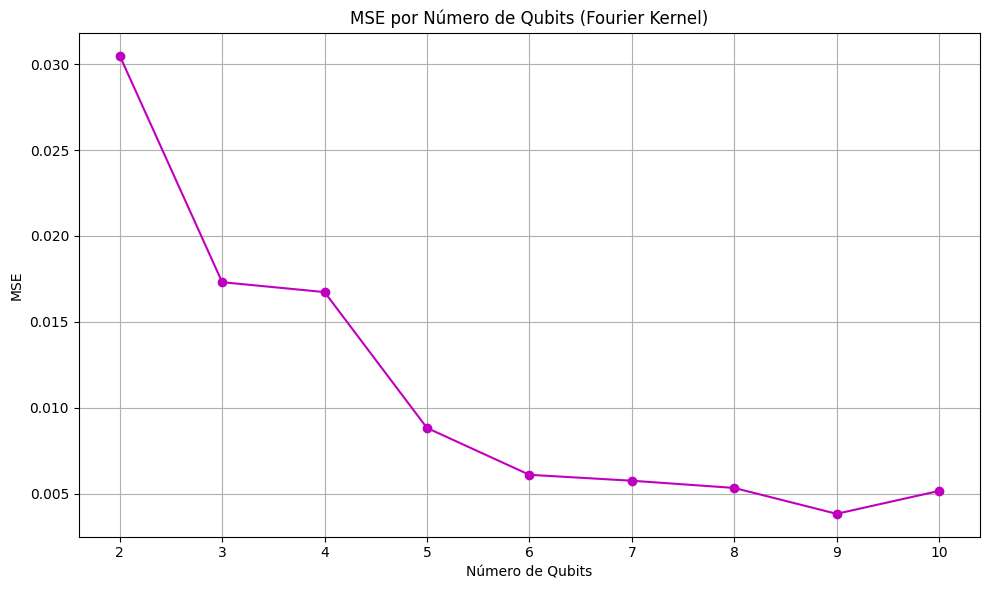

Kernel: 10_XY, MSE: 0.0052, R^2: 0.9356
  kernel  n_qubits       mse        r2  best_c  best_epsilon
0   2_XY         2  0.043455  0.465409       1          0.10
1   3_XY         3  0.021708  0.732943       5          0.01
2   4_XY         4  0.020833  0.743706       5          0.01
3   5_XY         5  0.010269  0.873675       5          0.01
4   6_XY         6  0.007867  0.903223       5          0.01
5   7_XY         7  0.007465  0.908167       5          0.01
6   8_XY         8  0.006764  0.916792       5          0.01
7   9_XY         9  0.004323  0.946820       5          0.01
8  10_XY        10  0.005236  0.935585       5          0.01


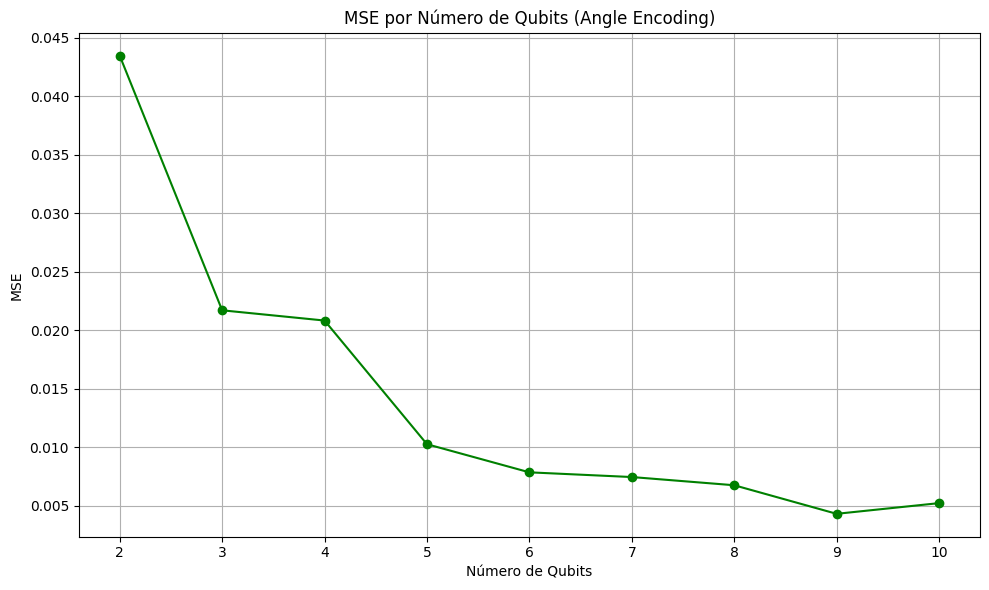

In [7]:
p_simple_process  = Process(target=run_simple_experiment)
p_fourier_process = Process(target=run_fourier_experiment)

p_simple_process.start()
p_fourier_process.start()
p_simple_process.join()
p_fourier_process.join()

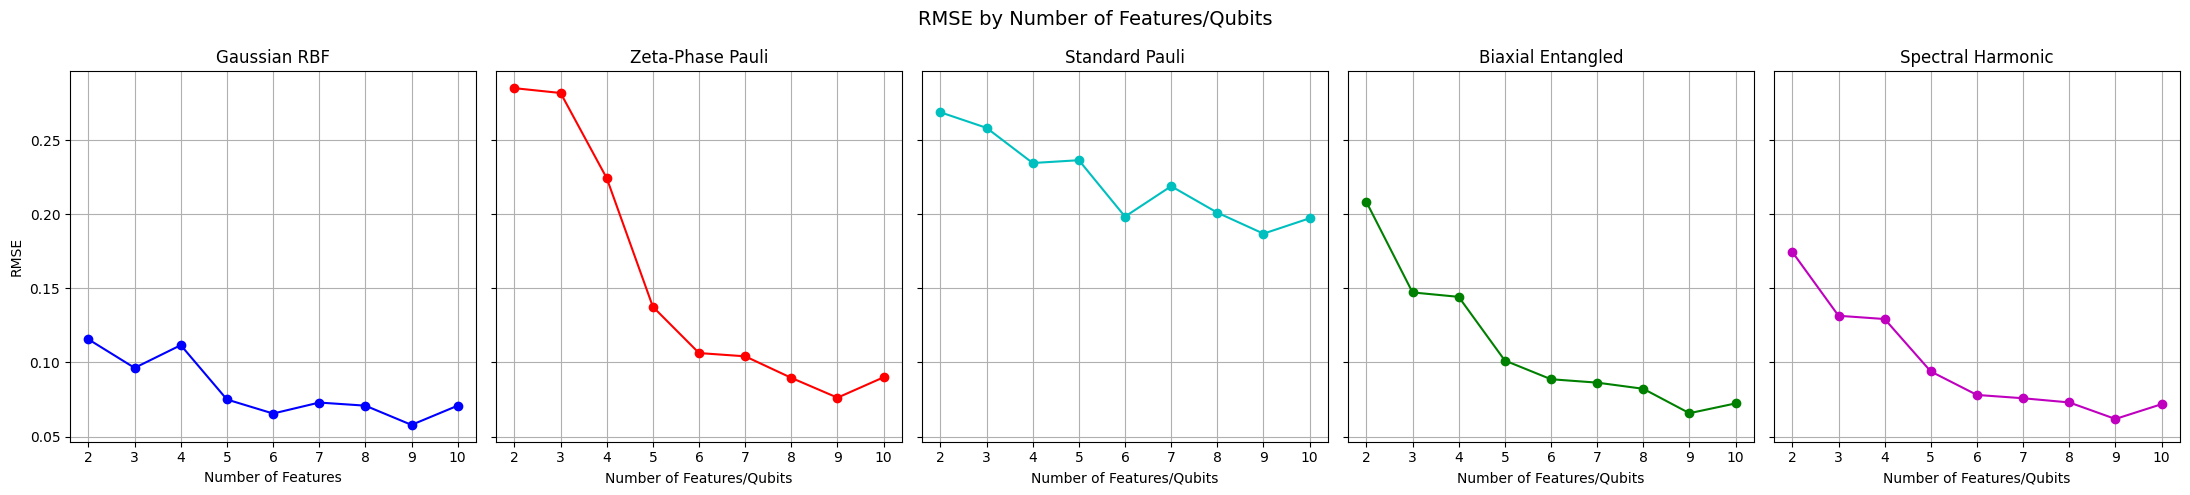

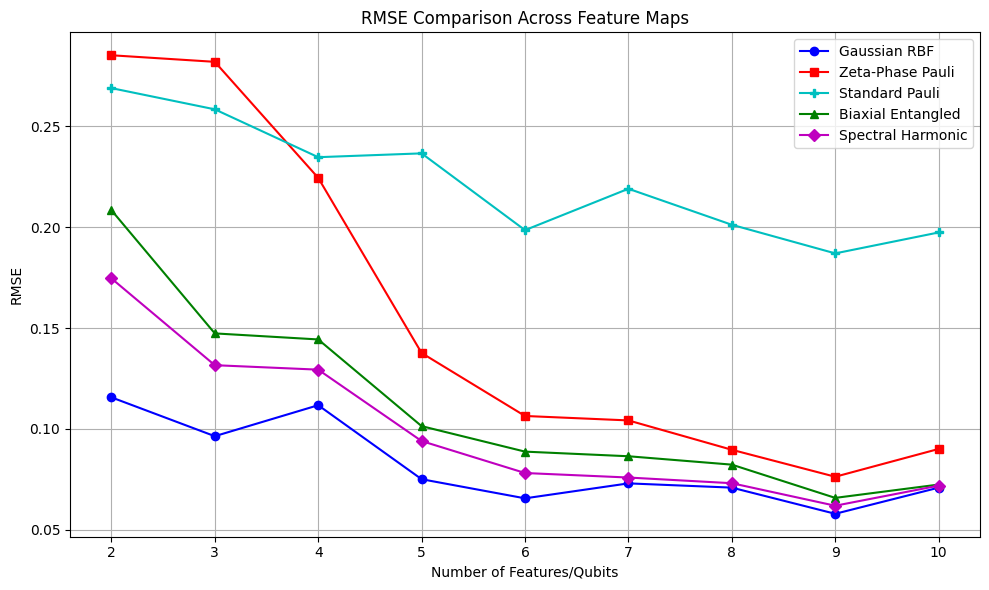

In [3]:
def plot_combined_results():
    classical_df = pd.read_csv("../results/experiment_15_v3/classical_experiment_results.csv")
    pauli_df = pd.read_csv("../results/experiment_15_v3/quantum_pauli_results.csv")
    pauli_default_df = pd.read_csv("../results/experiment_15_v3/quantum_pauli_results_default.csv")
    simple_df = pd.read_csv("../results/experiment_15_v3/simple_experiment_results.csv")
    fourier_df = pd.read_csv("../results/experiment_15_v3/fourier_experiment_results.csv")

    classical_df = classical_df.sort_values("Features")
    pauli_df = pauli_df.sort_values("N Features")
    pauli_default_df = pauli_default_df.sort_values("N Features")
    simple_df = simple_df.sort_values("n_qubits")
    fourier_df = fourier_df.sort_values("n_qubits")

    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
    axes[0].plot(classical_df["Features"], classical_df["RMSE"], 'b-o')
    axes[0].set_title("Gaussian RBF")
    axes[0].set_xlabel("Number of Features")
    axes[0].set_ylabel("RMSE")
    axes[0].set_xticks(range(2, 11))
    axes[0].grid(True)

    axes[1].plot(pauli_df["N Features"], pauli_df["RMSE"], 'r-o')
    axes[1].set_title("Zeta-Phase Pauli")
    axes[1].set_xlabel("Number of Features/Qubits")
    axes[1].set_xticks(range(2, 11))
    axes[1].grid(True)

    axes[2].plot(pauli_default_df["N Features"], pauli_default_df["RMSE"], 'c-o')
    axes[2].set_title("Standard Pauli")
    axes[2].set_xlabel("Number of Features/Qubits")
    axes[2].set_xticks(range(2, 11))
    axes[2].grid(True)

    axes[3].plot(simple_df["n_qubits"], simple_df["RMSE"], 'g-o')
    axes[3].set_title("Biaxial Entangled")
    axes[3].set_xlabel("Number of Features/Qubits")
    axes[3].set_xticks(range(2, 11))
    axes[3].grid(True)

    axes[4].plot(fourier_df["n_qubits"], fourier_df["RMSE"], 'm-o')
    axes[4].set_title("Spectral Harmonic")
    axes[4].set_xlabel("Number of Features/Qubits")
    axes[4].set_xticks(range(2, 11))
    axes[4].grid(True)

    fig.suptitle("RMSE by Number of Features/Qubits", fontsize=14)
    plt.tight_layout()
    plt.savefig("../results/experiment_15_v3/combined_results_subplots.png", dpi=160, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(classical_df["Features"], classical_df["RMSE"], 'b-o', label="Gaussian RBF")
    plt.plot(pauli_df["N Features"], pauli_df["RMSE"], 'r-s', label="Zeta-Phase Pauli")
    plt.plot(pauli_default_df["N Features"], pauli_default_df["RMSE"], 'c-P', label="Standard Pauli")
    plt.plot(simple_df["n_qubits"], simple_df["RMSE"], 'g-^', label="Biaxial Entangled")
    plt.plot(fourier_df["n_qubits"], fourier_df["RMSE"], 'm-D', label="Spectral Harmonic")
    plt.xlabel("Number of Features/Qubits")
    plt.ylabel("RMSE")
    plt.title("RMSE Comparison Across Feature Maps")
    plt.xticks(range(2, 11))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("../results/experiment_15_v3/combined_results.png", dpi=160, bbox_inches='tight')
    plt.show()


plot_combined_results()

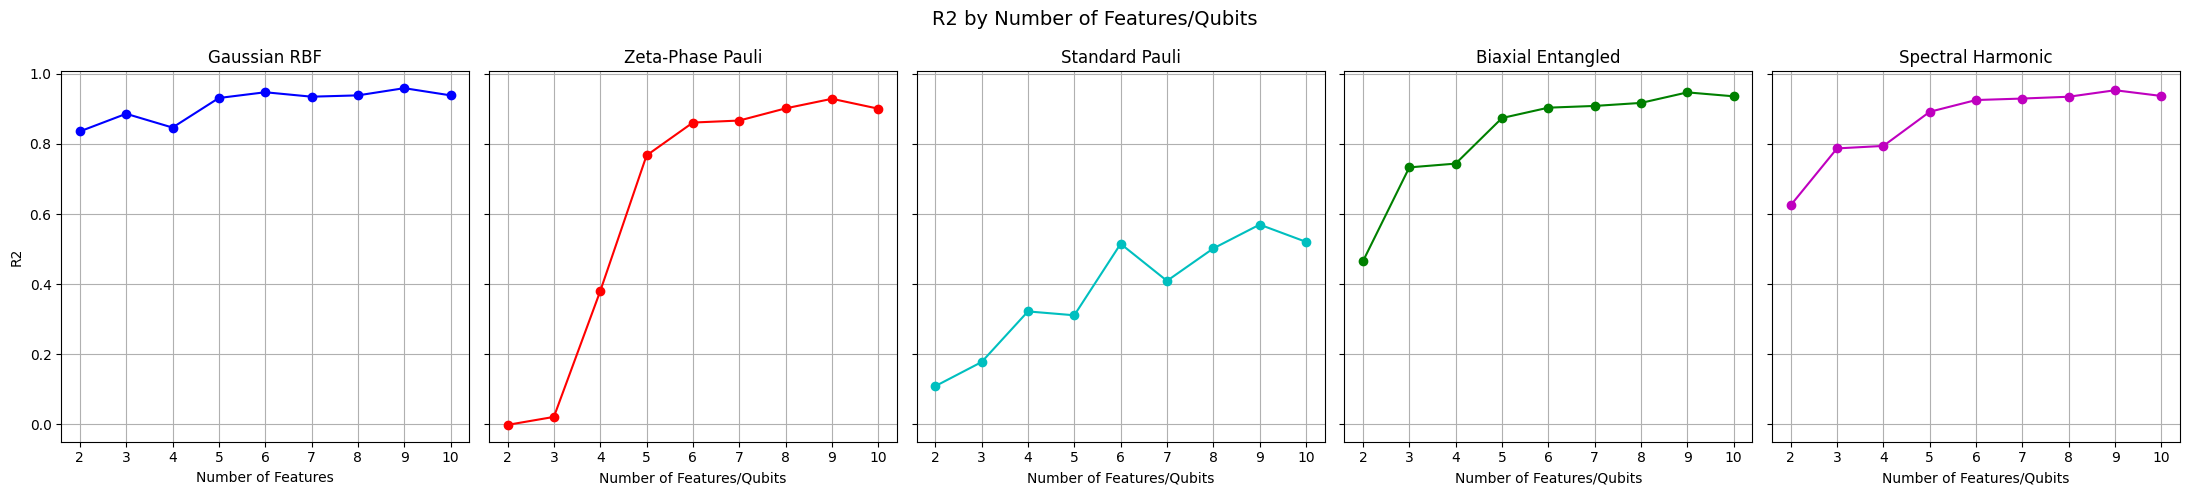

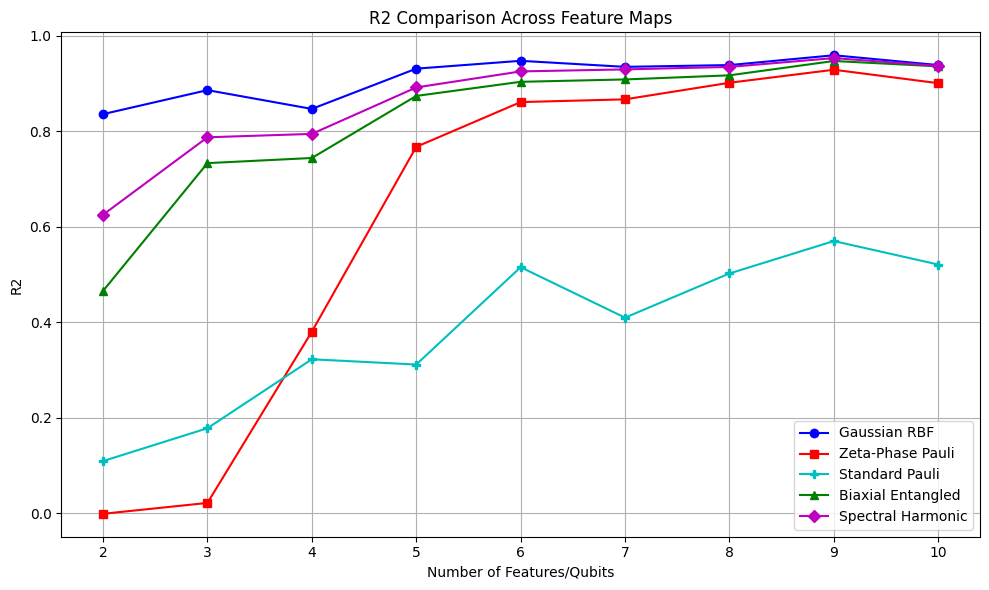

In [4]:
def plot_combined_results():
    classical_df = pd.read_csv("../results/experiment_15_v3/classical_experiment_results.csv")
    pauli_df = pd.read_csv("../results/experiment_15_v3/quantum_pauli_results.csv")
    pauli_default_df = pd.read_csv("../results/experiment_15_v3/quantum_pauli_results_default.csv")
    simple_df = pd.read_csv("../results/experiment_15_v3/simple_experiment_results.csv")
    fourier_df = pd.read_csv("../results/experiment_15_v3/fourier_experiment_results.csv")

    classical_df = classical_df.sort_values("Features")
    pauli_df = pauli_df.sort_values("N Features")
    pauli_default_df = pauli_default_df.sort_values("N Features")
    simple_df = simple_df.sort_values("n_qubits")
    fourier_df = fourier_df.sort_values("n_qubits")

    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

    axes[0].plot(classical_df["Features"], classical_df["R2"], "b-o")
    axes[0].set_title("Gaussian RBF")
    axes[0].set_xlabel("Number of Features")
    axes[0].set_ylabel("R2")
    axes[0].set_xticks(range(2, 11))
    axes[0].grid(True)

    axes[1].plot(pauli_df["N Features"], pauli_df["R2"], "r-o")
    axes[1].set_title("Zeta-Phase Pauli")
    axes[1].set_xlabel("Number of Features/Qubits")
    axes[1].set_xticks(range(2, 11))
    axes[1].grid(True)

    axes[2].plot(pauli_default_df["N Features"], pauli_default_df["R2"], "c-o")
    axes[2].set_title("Standard Pauli")
    axes[2].set_xlabel("Number of Features/Qubits")
    axes[2].set_xticks(range(2, 11))
    axes[2].grid(True)

    axes[3].plot(simple_df["n_qubits"], simple_df["R2"], "g-o")
    axes[3].set_title("Biaxial Entangled")
    axes[3].set_xlabel("Number of Features/Qubits")
    axes[3].set_xticks(range(2, 11))
    axes[3].grid(True)

    axes[4].plot(fourier_df["n_qubits"], fourier_df["R2"], "m-o")
    axes[4].set_title("Spectral Harmonic")
    axes[4].set_xlabel("Number of Features/Qubits")
    axes[4].set_xticks(range(2, 11))
    axes[4].grid(True)

    fig.suptitle("R2 by Number of Features/Qubits", fontsize=14)
    plt.tight_layout()
    plt.savefig("../results/experiment_15_v3/combined_results_subplots_r2.png", dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(classical_df["Features"], classical_df["R2"], "b-o", label="Gaussian RBF")
    plt.plot(pauli_df["N Features"], pauli_df["R2"], "r-s", label="Zeta-Phase Pauli")
    plt.plot(pauli_default_df["N Features"], pauli_default_df["R2"], "c-P", label="Standard Pauli")
    plt.plot(simple_df["n_qubits"], simple_df["R2"], "g-^", label="Biaxial Entangled")
    plt.plot(fourier_df["n_qubits"], fourier_df["R2"], "m-D", label="Spectral Harmonic")
    plt.xlabel("Number of Features/Qubits")
    plt.ylabel("R2")
    plt.title("R2 Comparison Across Feature Maps")
    plt.xticks(range(2, 11))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("../results/experiment_15_v3/combined_results_r2.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_combined_results()
